In [3]:
# Climate data analysis
import pandas as pd
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
print("Imports successful!")

Imports successful!


In [4]:
# Create an API call to the NOAA NCEI database
# change &stations line to change what station (ID number after : on NCEI)
# change &startDate line for specific station

ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1'

           '?dataset=daily-summaries'

           '&dataTypes=TAVG'

           '&stations=USR0000MMCF'

           '&startDate=2002-04-12'

           '&endDate=2026-07-12'

           '&units=standard')

ncei_url


'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TAVG&stations=USR0000MMCF&startDate=2002-04-12&endDate=2026-07-12&units=standard'

In [5]:
# Open and clean the data

mdi_df = pd.read_csv(

    ncei_url,

    na_values=["-99"],

    index_col="DATE",

    parse_dates=["DATE"]

)

mdi_df

,STATION,TAVG
DATE,,
2002-04-12,USR0000MMCF,49
2002-04-13,USR0000MMCF,53
2002-04-14,USR0000MMCF,48
2002-04-15,USR0000MMCF,40
2002-04-16,USR0000MMCF,51
...,...,...
2026-07-08,USR0000MMCF,68
2026-07-09,USR0000MMCF,76
2026-07-10,USR0000MMCF,73


In [6]:
# Keep only the TAVG column

mdi_df = mdi_df[["TAVG"]]

mdi_df.head()
mdi_df.tail()

,TAVG
DATE,
2026-07-08,68
2026-07-09,76
2026-07-10,73
2026-07-11,71
2026-07-12,70


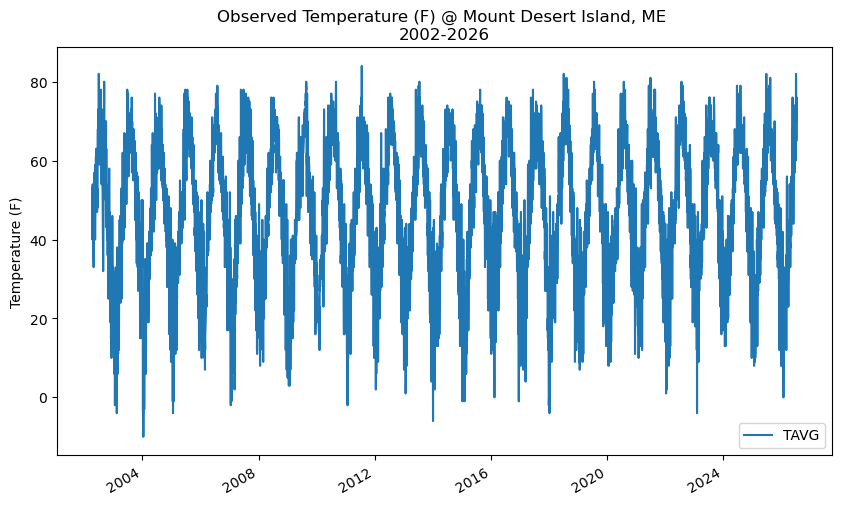

In [7]:
# Plot data with matplotlib

fig, ax = plt.subplots(figsize=(10,6))

mdi_df.plot(y='TAVG',

                 ax=ax,

                 ylabel='Temperature (F)',

                 xlabel='',

                 title='Observed Temperature (F) @ Mount Desert Island, ME \n2002-2026')

plt.show()

In [8]:
# Take the annual mean of the temperature data

ann_climate_df = mdi_df.resample('YE').mean()

ann_climate_df

,TAVG
DATE,
2002-12-31,49.742739
2003-12-31,44.682192
2004-12-31,43.894737
2005-12-31,44.926027
2006-12-31,48.252874
2007-12-31,44.819178
2008-12-31,45.897507
2009-12-31,44.697059
2010-12-31,50.017804


<Axes: xlabel='DATE'>

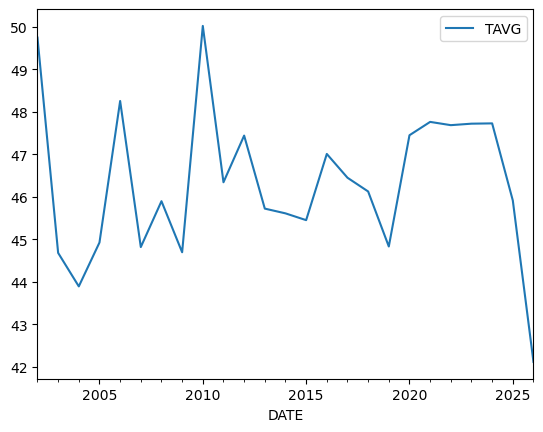

In [9]:
# Plot resampled the data

ann_climate_df.plot()

In [12]:
# Create an interactive plot with hvplot

ann_climate_plot = ann_climate_df.hvplot()

ann_climate_plot

:Curve   [DATE]   (TAVG)

In [13]:
# Save interactive plot as html to host on the web

hv.save(ann_climate_plot, 'mdi_plot.html')